In [1]:
import sys
sys.path.insert(1, '../Codes_1Dtree')
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0,1,2,3"

In [2]:
import torch
from torch_geometric.loader import DataLoader
from data.graph_dataset import OneDDatasetBuilder, OneDDatasetLoader, normalize, dataset_to_loader
# from networks.gcn import GraphUNet, RecurrentFormulationNet
from networks.gcnv3 import RecurrentFormulationNet
import matplotlib.pyplot as plt

from data.graph_dataset import batchgraph_generation_wise

In [3]:
class objectview(object):
    def __init__(self, d) -> None:
        self.__dict__ = d
    def setattr(self, attr_name, attr_value):
        self.__dict__[attr_name] = attr_value

args = objectview({
    'n_field': 2,
    'n_meshfield': 16,
    'hidden_size': 32,
    'latent_size': 32,
    'aggr': 'sum',
    'act': 'mish',
    'dropout': 0.2,
    'device': torch.device('cuda:1' if torch.cuda.is_available() else 'cpu'),
    'lr': 1e-6,
    'weight_decay': 1e-3,
    'n_epoch': 200,
    'alpha': 0.5,
    'batchsize': None,
    'timestep': 8,
    'timeslice_hops': 0,
    'timeslice_steps': 1,
    'n_data_per_batch': 1,
    'criterion': torch.nn.MSELoss(),
    'plot': False
})

In [4]:
dataset = OneDDatasetLoader(
    root_dir='/data1/tam/downloaded_datasets_Static_v1',
    sub_dir='normalized',
    subjects='all',
    time_names=[str(i).zfill(3) for i in range(201)],
    data_type = torch.float32
)

In [5]:
model = RecurrentFormulationNet(
    n_field=args.n_field,
    n_meshfield=args.n_meshfield,
    hidden_size=args.hidden_size,
    latent_size=args.latent_size,
    act=args.act,
    use_time_feature=True,
    dropout=args.dropout,
    use_hidden=True
)
setattr(model, 'name', 'PARC_GCN_UNet_full')
# model = model.to(args.device)
model.load_state_dict(torch.load(f'models/{model.name}_node1_epoch200.pth'))

<All keys matched successfully>

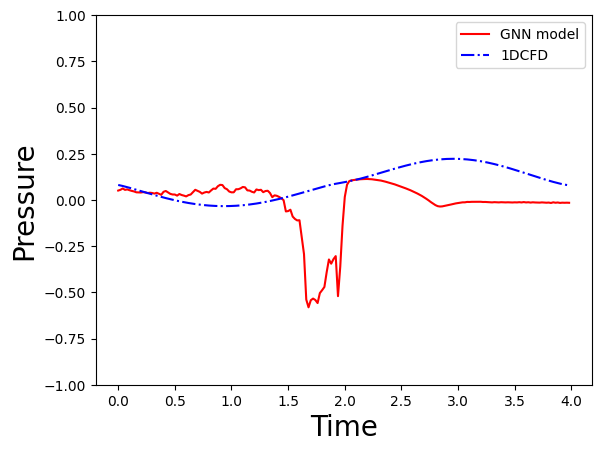

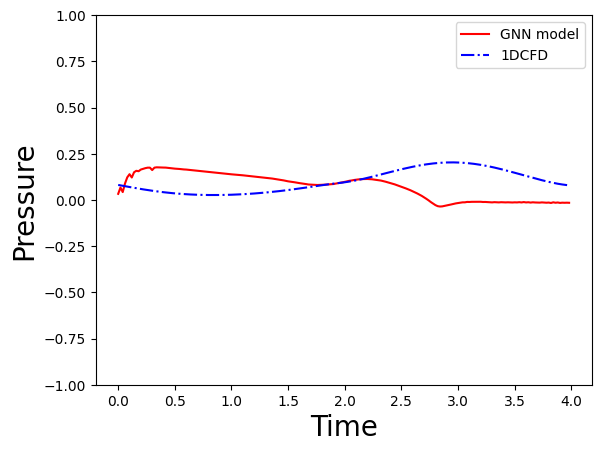

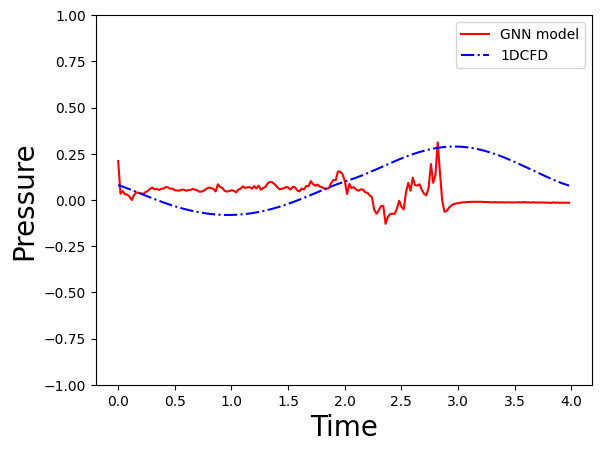

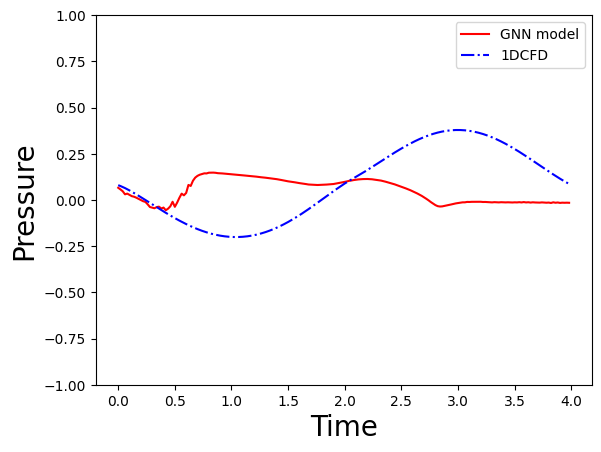

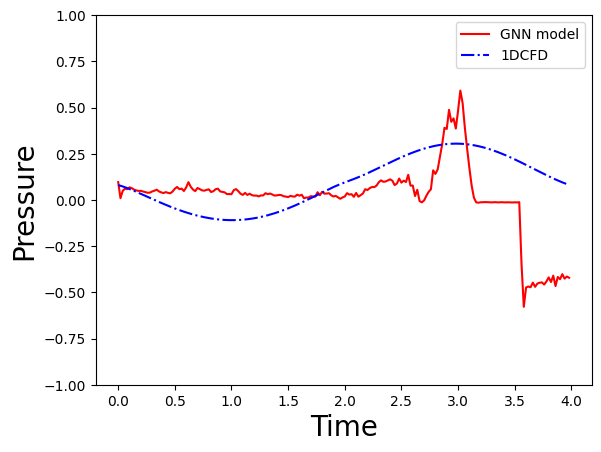

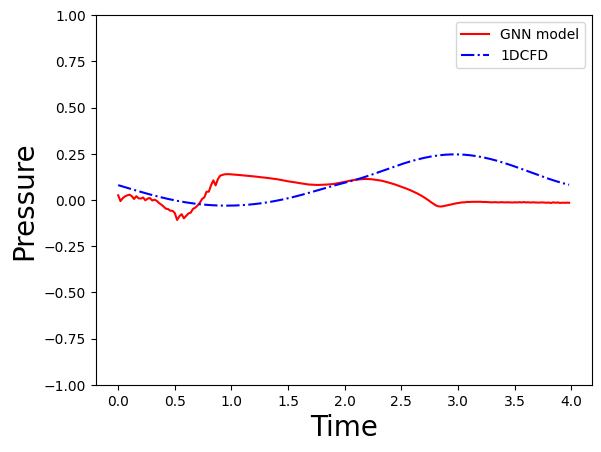

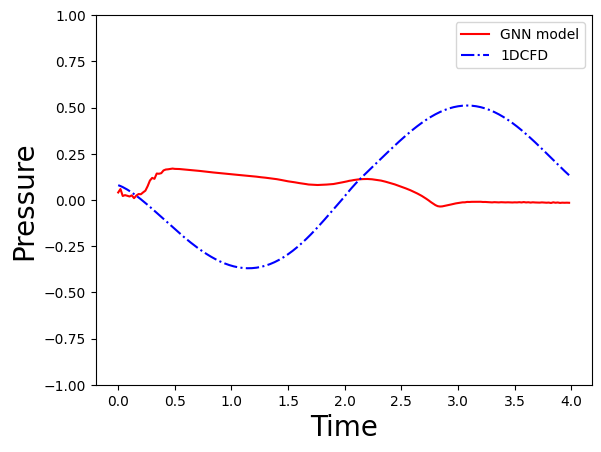

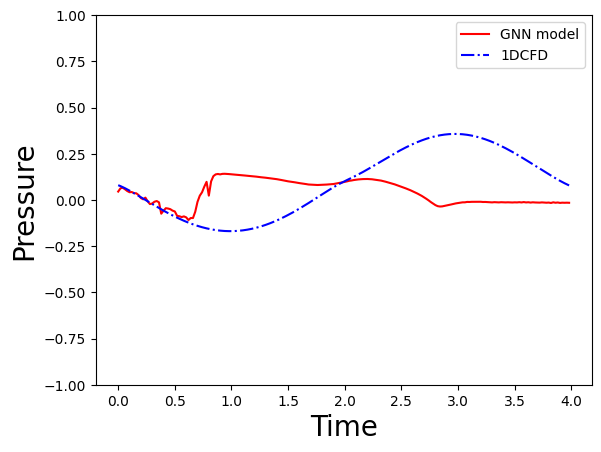

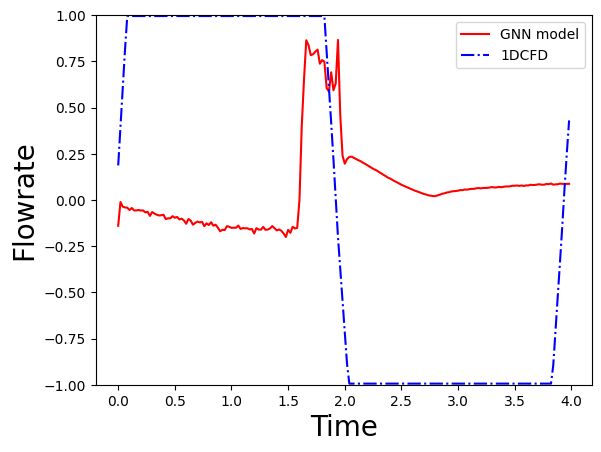

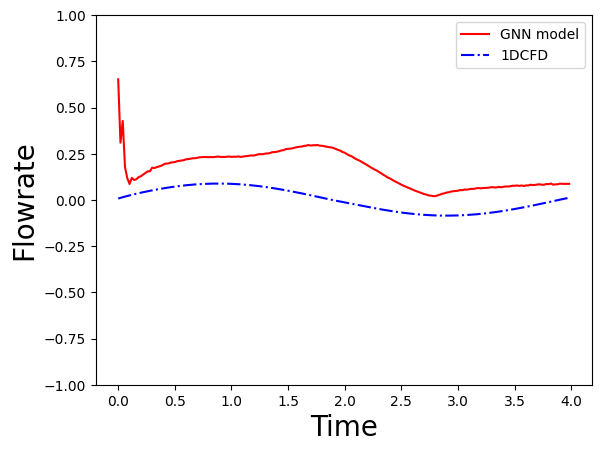

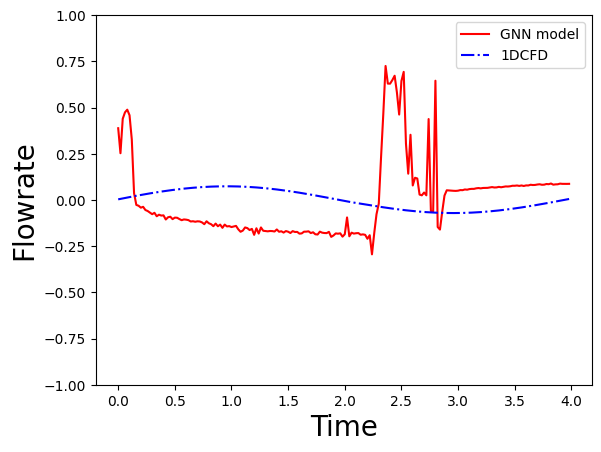

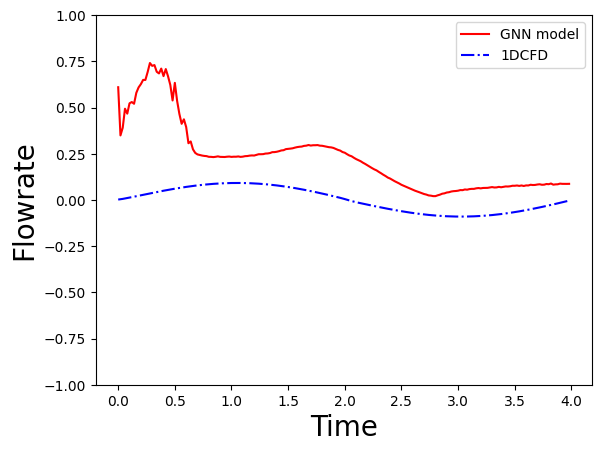

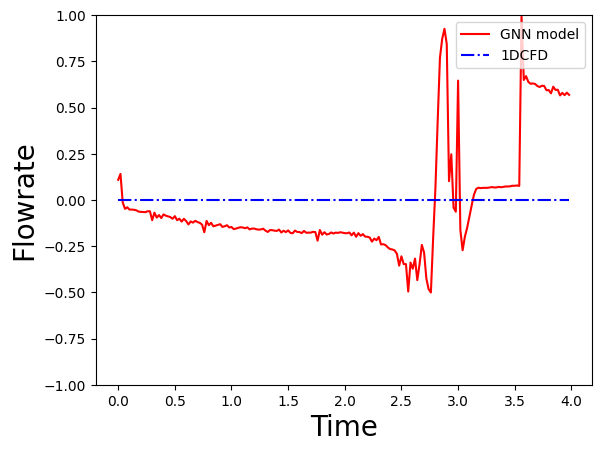

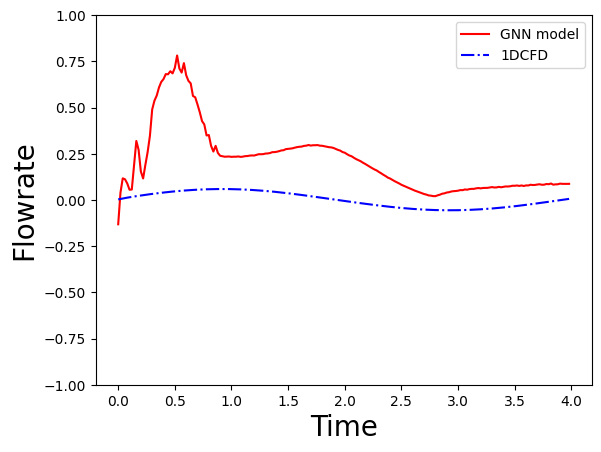

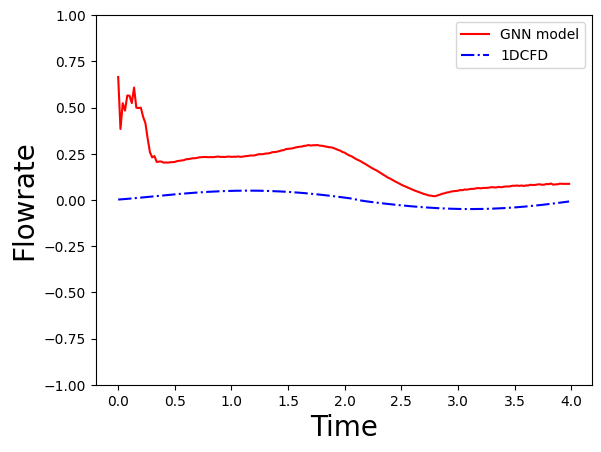

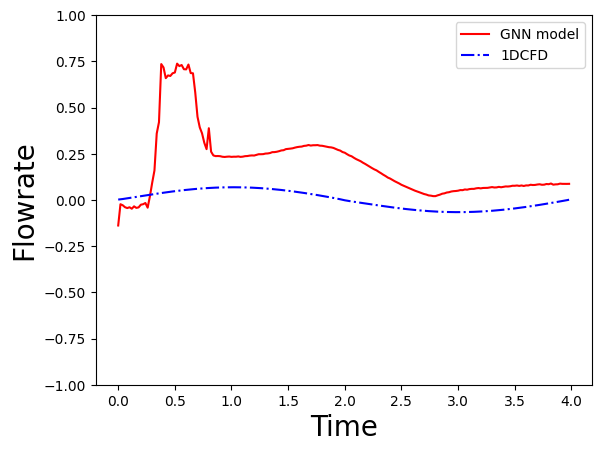

In [6]:
data = dataset[39]

F_true = torch.cat([data.pressure.unsqueeze(2), data.flowrate.unsqueeze(2)], dim=2) \
            .float()#.to(args.device)
F_dot_true = torch.cat([data.pressure_dot.unsqueeze(2), data.flowrate_dot.unsqueeze(2)], dim=2) \
            .float()#.to(args.device)
##
F_0 = F_true[:,0,:]
edge_index = data.edge_index#.to(args.device)
node_attr = data.node_attr.float()#.to(args.device)
F_true = F_true[:,1:,:]
F_dot_true = F_dot_true[:,1:,:]
time = data.time.float()#.to(args.device)
##
with torch.no_grad():
    F_pred, F_dot_pred = model.forward(
        F_0=F_0,
        edge_index=edge_index,
        meshfield=node_attr,
        time=time,
        n_time=data.number_of_timesteps - 1
    )
    # loss = args.criterion(F_pred, F_true)*args.alpha + (1.-args.alpha)*args.criterion(F_dot_pred, F_dot_true)


##
node_list = [100, 1000, 2000, 5000, 10000, 20000, 30000, 40000]
## Draw pressure
import matplotlib.pyplot as plt
for i_node in node_list:
    i_field = 0
    y_pred = F_pred.cpu().numpy()[i_node,:,i_field]
    y_true = F_true.cpu().numpy()[i_node,:,i_field]
    # print(y_true, y_pred)
    x = [i * 4.0 /200 for i in range(y_pred.shape[0])]
    # print(data.node_attr.numpy()[i_node, 6])
    plt.ylim(-1,1)
    plt.plot(x, y_pred, c='red', label='GNN model')
    plt.plot(x, y_true, c='blue', linestyle='dashdot', label='1DCFD')
    # plt.ylim([-1,1])
    plt.legend(loc='upper right')
    plt.ylabel('Pressure', fontsize=20)
    plt.xlabel('Time', fontsize=20)
    plt.show()

##
# node_list = [1000, 5000, 20000, 40000]
## Draw pressure
import matplotlib.pyplot as plt
for i_node in node_list:
    i_field = 1
    y_pred = F_pred.cpu().numpy()[i_node,:,i_field]
    y_true = F_true.cpu().numpy()[i_node,:,i_field]
    # print(y_true, y_pred)
    x = [i * 4.0 /200 for i in range(y_pred.shape[0])]
    # print(data.node_attr.numpy()[i_node, 6])
    plt.ylim(-1,1)
    plt.plot(x, y_pred, c='red', label='GNN model')
    plt.plot(x, y_true, c='blue', linestyle='dashdot', label='1DCFD')
    # plt.ylim([-1,1])
    plt.legend(loc='upper right')
    plt.ylabel('Flowrate', fontsize=20)
    plt.xlabel('Time', fontsize=20)
    plt.show()


In [7]:
fold_size = 5
fold = [list(range(i*fold_size, (i+1)*fold_size)) for i in range(8)]
n_train_fold = 7
for i in range(n_train_fold):
    test_subset = fold[i]
    train_subset = []
    for j in range(n_train_fold):
        if j != i:
            train_subset += fold[j]
    print(train_subset, test_subset)

[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34] [0, 1, 2, 3, 4]
[0, 1, 2, 3, 4, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34] [5, 6, 7, 8, 9]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34] [10, 11, 12, 13, 14]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34] [15, 16, 17, 18, 19]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34] [20, 21, 22, 23, 24]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 30, 31, 32, 33, 34] [25, 26, 27, 28, 29]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29] [30, 31, 32, 33, 34]


In [8]:
import sys
sys.path.insert(1, '../Codes_1Dtree')
import torch
from networks.gcnv3 import GraphUNet

model = GraphUNet(
    in_channels=3,
    hidden_channels=32,
    out_channels=2,
    depth=3,
    sum_res=True,
    act='relu',
    block_depth=2,
    dropout=0.1,
)

edge_index = torch.tensor([[1,2,3,4,5],[0,1,1,2,2]]).type(torch.LongTensor)
x = torch.randn((6,3))

model.ups

ModuleList(
  (0-2): 3 x Sequential(
    (0) - ProcessorLayer(): x, edge_index -> x
    (1) - ReLU(): x -> x
    (2) - ProcessorLayer(): x, edge_index -> x
    (3) - Dropout(p=0.1, inplace=True): x -> x
  )
)